In [1]:
# !pip install seaborn
# !pip install torch torchvision
# !pip install scikit-learn
# !pip install pandas
# !pip install matplotlib
# !pip install kagglehub

In [2]:
import kagglehub
import os

# Download latest version
output_dir = 'data'
dataset_handle = "navoneel/brain-mri-images-for-brain-tumor-detection"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

download_path = kagglehub.dataset_download(dataset_handle, output_dir=output_dir)

print(download_path)






/Users/aid133/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


data


# Setting seed

- setting seed allows for reproducibility, and reduce randomness

In [3]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

# Learning Approach

- we employ the dataset of brain imaging scan that we can obtain from kaggle for this demo
https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection

- this dataset contains 253 images of brain scans
    - 98 of which has no tumor
    - 155 of which has a tumor
- we aim to be able to predict whether an unseen image can be classified to have a tumor or not
- for this task, we likely need a computer vision model that is already pre-trained, and that we would do transfer learning.
- this ensures that we are able to inherit the rich feature representations of the pre-trained model and at the same time reducing training time and computational costs

# EDA

- for a basic EDA, lets ensure that our dataset contains values as expected

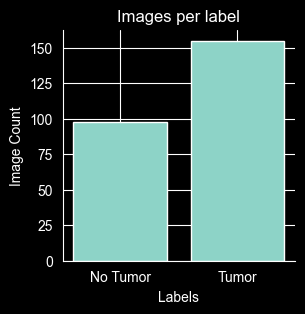

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os


BASE_PATH = 'data'


no_tumor_images = os.listdir(f'{BASE_PATH}/no')
tumor_images = os.listdir(f'{BASE_PATH}/yes')

labels = ['No Tumor', 'Tumor']
counts = [len(no_tumor_images), len(tumor_images)]

plt.figure(figsize=(3,3))
plt.bar(labels, counts)
plt.xlabel('Labels')
plt.ylabel('Image Count')
plt.title('Images per label')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

In [5]:
print(len(no_tumor_images))
print(len(tumor_images))

98
155


# Data imbalance

- because of the imbalance (98 vs 155) in the dataset we have to do augmentations to prevent biases
- the safest augmentation we can do for medical realistic images is a slight rotation
- we need to generate 155 - 98 = 57 of such augmentations


In [6]:
from torchvision import transforms
from PIL import Image


aug_dir = f'{BASE_PATH}/no_aug'

os.makedirs(aug_dir, exist_ok=True)

transform = transforms.RandomRotation(degrees=10)

NUM_IMAGES_TO_AUGMENT = 57

no_tumor_aug_images = []

for img_name in no_tumor_images:
    if NUM_IMAGES_TO_AUGMENT <= 0 :
        break
    img_path = os.path.join(f"{BASE_PATH}/no", img_name)
    img = Image.open(img_path).convert('RGB')

    aug_img = transform(img)

    # we will take the path as name to differentiate
    save_name = img_name
    print(save_name)
    aug_img.save(os.path.join(aug_dir, save_name))
    no_tumor_aug_images.append(save_name)
    NUM_IMAGES_TO_AUGMENT -= 1



30 no.jpg
22 no.jpg
41 no.jpg
14 no.jpg
no 10.jpg
18 no.jpg
no 9.png
no 7.jpeg
no 8.jpg
no.jpg
3 no.jpg
43 no.jpg
20 no.jpg
32 no.jpg
2 no.jpeg
N15.jpg
no 99.jpg
no 98.jpg
No11.jpg
7 no.jpg
12 no.jpg
No13.jpg
44no.jpg
N16.jpg
N17.jpg
28 no.jpg
36 no.jpg
No12.jpg
47 no.jpg
24 no.jpg
No16.jpg
10 no.jpg
26 no.jpg
45 no.jpg
no 923.jpg
38 no.jpg
No17.jpg
49 no.jpg
34 no.jpg
1 no.jpeg
no 100.jpg
No15.jpg
5 no.jpg
N11.jpg
no 89.jpg
No14.jpg
9 no.jpg
No19.jpg
no 90.jpg
N20.JPG
N21.jpg
No18.jpg
15 no.jpg
19 no.jpg
N22.JPG
no 92.jpg
31 no.jpg


# Adding image path into a pd dataframe

- to be able to manage the data effectively, we can place the data into a pandas dataframe, in this way we can transform and view the dataset easily

In [7]:
import os
import pandas as pd

data = []

for img in no_tumor_images :
    data.append({
        "filepath" : "no/" + img,
        "label" : 0 ,
        "is_aug" : False,
        "source" : "no/" + img
    })

for img in tumor_images :
    data.append({
        "filepath" : "yes/" + img,
        "label" : 1,
        "is_aug" : False,
        "source" : "yes/" + img
    })

# we track the source of the augmented files
for img in no_tumor_aug_images:
    data.append({
        "filepath": "no_aug/" + img,
        "label": 0,
        "is_aug": True,
        "source": "no/" + img
    })

df = pd.DataFrame(data)

df



,filepath,label,is_aug,source
0,no/30 no.jpg,0,False,no/30 no.jpg
1,no/22 no.jpg,0,False,no/22 no.jpg
2,no/41 no.jpg,0,False,no/41 no.jpg
3,no/14 no.jpg,0,False,no/14 no.jpg
4,no/no 10.jpg,0,False,no/no 10.jpg
...,...,...,...,...
305,no_aug/15 no.jpg,0,True,no/15 no.jpg
306,no_aug/19 no.jpg,0,True,no/19 no.jpg
307,no_aug/N22.JPG,0,True,no/N22.JPG
308,no_aug/no 92.jpg,0,True,no/no 92.jpg


# Choosing a model

Looking into the computer vision models we have available for this task, there are a few feasible and popular models we can choose from

- VGG16 - 138M (CNN)
    - Deep but simple stacked convolutions
    - very heavy, high memory usage
    - prone to overfitting due to large parameter count
- ResNet-18 - 11M (CNN)
    - Residual connections
    - Stable gradients even in deeper variants
- EfficientNet-B0 - 5.3M (CNN)
    - Compound scaling (depth, width, resolution )
    - smallest, most parameter efficient, designed for optimal scaling
- ViT - 86M+ (Transformer)
    - self-attention on image patches
    - requires large datasets to perform well


since efficientNet is good for smaller datasets , and requires less compute, it may be a good choice

## Approach

- since EfficientNet-B0 is pre-trained on ImageNet, it will be better for us to do transfer learning

1. We first want to freeze earlier layers for these reasons
    1. we want to preserve pretrained general-purpose knowledge
    2. deeper layers contain more task-specific and high-level features
    3. Provide regularization
2. We then want to train only the classification head
3. After initial convergence , we can do gradual fine tuning ( optional )
    1. this step has to be trained with a very low learning rate
    2. model will be able to further specialize for medical features like irregular shapes, subtle texture differences, low-contrast regions

# Further Data preparation

## Resizing to (224, 224, 3)

- EfficientNetB0 works best with images of (224, 224, 3) , so we convert the images to the set size

## Regularization

aim of regularization is to prevent models from overfitting, the most common techniques are :

- Dropout
    - randomly deactivates portions of neurons during training, forcing the model to learn more robust and indepedent features Í
    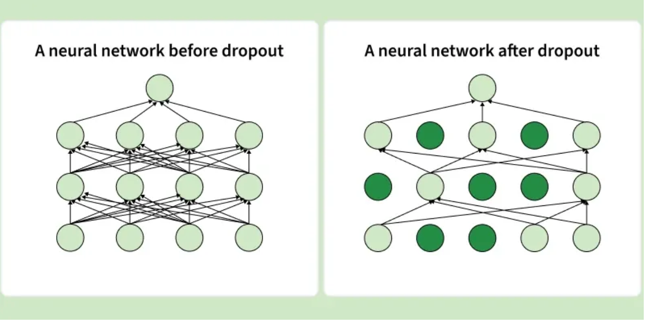

- Early Stopping
    - halts training when a model's performance stop improving
- Weight decay (?)
    - since likely we are freezing many layers , the impact of this technique may be low

In [8]:
from PIL import Image

image = Image.open('data/no/1 no.jpeg')
print(image.mode)

L


In [9]:
from torchvision import transforms
import torch
import os
from PIL import Image

def resize_image(image_path, target_size=(224,224)) :
    #     this function resize the image to (224,224,3)

    transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])


    try :
        image = Image.open(image_path)

        # takes longer for training but we dont lose the general features
        image = image.convert('RGB')

        image_tensor = transform(image)

        return image_tensor

    except FileNotFoundError:
        print(f"Error: Image file not found {image_path}")

        return None
    except Exception as e :
        print(f"Error processing image: {str(e)}")
        return None



def create_directories(output_dir):
    #     this function create the directories for the new images if not exists
    try :
        os.makedirs(output_dir, exist_ok=True)
        print(f"Directory created at: {output_dir}")
    except Exception as e :
        print(f"Error creating directory: {str(e)}")

def process_image_directory(base_path, input_dir, output_dir, label, prefix="") :
    # this function takes all the images from a directory and resize them

    # returns list of dictionaries with images info for Dataframe
    create_directories(output_dir)

    valid_extensions = {'.jpg' , '.jpeg', '.png', '.gif' , '.bmp', '.webp'}

    image_info_list = []
    image_files = []
    print(f"{base_path}/{input_dir}")

    try :

        for f in os.listdir(f"{base_path}/{input_dir}"):
            if os.path.splitext(f)[1].lower() in valid_extensions :
                image_files.append(f)

        for idx, filename in enumerate(image_files):
            image_path = os.path.join(base_path, input_dir, filename)
            print(image_path, 'image_path')
            image_tensor = resize_image(image_path)

            if image_tensor is None :
                print("image_tensor is empty")
                continue

            print(filename, 'filename')

            output_filename_without_ext = os.path.splitext(filename)[0]

            print(output_filename_without_ext, 'output_filename_without_ext')

            tensor_filename = f"{prefix}{output_filename_without_ext}.pt"

            output_path = os.path.join(output_dir, tensor_filename)

            torch.save(image_tensor, output_path)

            image_info_list.append({
                'original_image' : filename,
                'image_path' : f"{input_dir}/{filename}",
                'tensor_path' : output_path,
                'shape' : tuple(image_tensor.shape)
            })

            if idx % 10 == 0 :
                print(f"Processed {idx}/{len(image_files)} images")

        print(f"Successfully processed {len(image_info_list)} images")
        return image_info_list

    except Exception as e :
        print(f"Error processing directory: {str(e)}")
        return []


def create_dataframe(*image_info_lists):
    # this function creates a dataframe to be prepared to be passed into the efficientNetB0 model

    all_info = [item for sublist in image_info_lists for item in sublist]

    if not all_info :
        print("Error : No image info provided")
        return

    try :
        df = pd.DataFrame(all_info)
        return df
    except Exception as e :
        print(f"Error creating Dataframe: {str(e)}")
        return
    pass

NO_DIR = "no"
YES_DIR = "yes"
NO_DIR_AUG = "no_aug"
print(BASE_PATH, "BP")
NO_DIR_INFO = process_image_directory(BASE_PATH, NO_DIR, "resized/no", 0, "resized_")
YES_DIR_INFO = process_image_directory(BASE_PATH, YES_DIR, "resized/yes", 1, "resized_")
NO_DIR_AUG_INFO = process_image_directory(BASE_PATH, NO_DIR_AUG, "resized/no_aug", 0, "resized_aug_")

ALL_INFO = NO_DIR_INFO + YES_DIR_INFO + NO_DIR_AUG_INFO

tmp_df = pd.DataFrame(ALL_INFO)

tmp_df












data BP
Directory created at: resized/no
data/no
data/no/30 no.jpg image_path
30 no.jpg filename
30 no output_filename_without_ext
Processed 0/98 images
data/no/22 no.jpg image_path
22 no.jpg filename
22 no output_filename_without_ext
data/no/41 no.jpg image_path
41 no.jpg filename
41 no output_filename_without_ext
data/no/14 no.jpg image_path
14 no.jpg filename
14 no output_filename_without_ext
data/no/no 10.jpg image_path
no 10.jpg filename
no 10 output_filename_without_ext
data/no/18 no.jpg image_path
18 no.jpg filename
18 no output_filename_without_ext
data/no/no 9.png image_path
no 9.png filename
no 9 output_filename_without_ext
data/no/no 7.jpeg image_path
no 7.jpeg filename
no 7 output_filename_without_ext
data/no/no 8.jpg image_path
no 8.jpg filename
no 8 output_filename_without_ext
data/no/no.jpg image_path
no.jpg filename
no output_filename_without_ext
data/no/3 no.jpg image_path
3 no.jpg filename
3 no output_filename_without_ext
Processed 10/98 images
data/no/43 no.jpg image

,original_image,image_path,tensor_path,shape
0,30 no.jpg,no/30 no.jpg,resized/no/resized_30 no.pt,"(3, 224, 224)"
1,22 no.jpg,no/22 no.jpg,resized/no/resized_22 no.pt,"(3, 224, 224)"
2,41 no.jpg,no/41 no.jpg,resized/no/resized_41 no.pt,"(3, 224, 224)"
3,14 no.jpg,no/14 no.jpg,resized/no/resized_14 no.pt,"(3, 224, 224)"
4,no 10.jpg,no/no 10.jpg,resized/no/resized_no 10.pt,"(3, 224, 224)"
...,...,...,...,...
305,15 no.jpg,no_aug/15 no.jpg,resized/no_aug/resized_aug_15 no.pt,"(3, 224, 224)"
306,19 no.jpg,no_aug/19 no.jpg,resized/no_aug/resized_aug_19 no.pt,"(3, 224, 224)"
307,N22.JPG,no_aug/N22.JPG,resized/no_aug/resized_aug_N22.pt,"(3, 224, 224)"
308,no 92.jpg,no_aug/no 92.jpg,resized/no_aug/resized_aug_no 92.pt,"(3, 224, 224)"


In [10]:
df_merged = df.merge(
    tmp_df,
    left_on="filepath",
    right_on="image_path",
    how="inner"
)

df_merged

,filepath,label,is_aug,source,original_image,image_path,tensor_path,shape
0,no/30 no.jpg,0,False,no/30 no.jpg,30 no.jpg,no/30 no.jpg,resized/no/resized_30 no.pt,"(3, 224, 224)"
1,no/22 no.jpg,0,False,no/22 no.jpg,22 no.jpg,no/22 no.jpg,resized/no/resized_22 no.pt,"(3, 224, 224)"
2,no/41 no.jpg,0,False,no/41 no.jpg,41 no.jpg,no/41 no.jpg,resized/no/resized_41 no.pt,"(3, 224, 224)"
3,no/14 no.jpg,0,False,no/14 no.jpg,14 no.jpg,no/14 no.jpg,resized/no/resized_14 no.pt,"(3, 224, 224)"
4,no/no 10.jpg,0,False,no/no 10.jpg,no 10.jpg,no/no 10.jpg,resized/no/resized_no 10.pt,"(3, 224, 224)"
...,...,...,...,...,...,...,...,...
305,no_aug/15 no.jpg,0,True,no/15 no.jpg,15 no.jpg,no_aug/15 no.jpg,resized/no_aug/resized_aug_15 no.pt,"(3, 224, 224)"
306,no_aug/19 no.jpg,0,True,no/19 no.jpg,19 no.jpg,no_aug/19 no.jpg,resized/no_aug/resized_aug_19 no.pt,"(3, 224, 224)"
307,no_aug/N22.JPG,0,True,no/N22.JPG,N22.JPG,no_aug/N22.JPG,resized/no_aug/resized_aug_N22.pt,"(3, 224, 224)"
308,no_aug/no 92.jpg,0,True,no/no 92.jpg,no 92.jpg,no_aug/no 92.jpg,resized/no_aug/resized_aug_no 92.pt,"(3, 224, 224)"


In [11]:
df_orig = df_merged[df_merged["is_aug"] == False].reset_index(drop=True)

df_aug = df_merged[df_merged["is_aug"] == True].reset_index(drop=True)

df_aug

,filepath,label,is_aug,source,original_image,image_path,tensor_path,shape
0,no_aug/30 no.jpg,0,True,no/30 no.jpg,30 no.jpg,no_aug/30 no.jpg,resized/no_aug/resized_aug_30 no.pt,"(3, 224, 224)"
1,no_aug/22 no.jpg,0,True,no/22 no.jpg,22 no.jpg,no_aug/22 no.jpg,resized/no_aug/resized_aug_22 no.pt,"(3, 224, 224)"
2,no_aug/41 no.jpg,0,True,no/41 no.jpg,41 no.jpg,no_aug/41 no.jpg,resized/no_aug/resized_aug_41 no.pt,"(3, 224, 224)"
3,no_aug/14 no.jpg,0,True,no/14 no.jpg,14 no.jpg,no_aug/14 no.jpg,resized/no_aug/resized_aug_14 no.pt,"(3, 224, 224)"
4,no_aug/no 10.jpg,0,True,no/no 10.jpg,no 10.jpg,no_aug/no 10.jpg,resized/no_aug/resized_aug_no 10.pt,"(3, 224, 224)"
5,no_aug/18 no.jpg,0,True,no/18 no.jpg,18 no.jpg,no_aug/18 no.jpg,resized/no_aug/resized_aug_18 no.pt,"(3, 224, 224)"
6,no_aug/no 9.png,0,True,no/no 9.png,no 9.png,no_aug/no 9.png,resized/no_aug/resized_aug_no 9.pt,"(3, 224, 224)"
7,no_aug/no 7.jpeg,0,True,no/no 7.jpeg,no 7.jpeg,no_aug/no 7.jpeg,resized/no_aug/resized_aug_no 7.pt,"(3, 224, 224)"
8,no_aug/no 8.jpg,0,True,no/no 8.jpg,no 8.jpg,no_aug/no 8.jpg,resized/no_aug/resized_aug_no 8.pt,"(3, 224, 224)"
9,no_aug/no.jpg,0,True,no/no.jpg,no.jpg,no_aug/no.jpg,resized/no_aug/resized_aug_no.pt,"(3, 224, 224)"


In [12]:
import torchvision.models as models
import torch.nn as nn

def build_model() :
    model = models.efficientnet_b0(weights="IMAGENET1K_V1")


    for param in model.features.parameters() :
        param.requires_grad = False

    for param in model.features[-1].parameters():
        param.requires_grad = True

    # change classifier to become binary
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 2)  # 2 classes (0 or 1)
    )

    return model

model = build_model()

# Now splitting into training and test set

- as our dataset is small, we opt for kfold cross validation, to provide the best representation of how well our model can perform
- for loss functions, we choose CrossEntropyLoss for classification problems like this
- for epoch we choose 10 , due to our choice of kfolds and lack of hardware, this could potentially be increase to check on whether it could further converge
- later on we increase the epoch to 100 on a 30/70 train test split to see if that converges better

**Notes**

- since we are using cross validation , we need to ensure that if the augment data is inside the train, it SHOULD NOT be inside the test , vice versa.


In [13]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

criterion = nn.CrossEntropyLoss()
# initial training , high learning rate is okay
learning_rate = 0.001
num_epochs = 10

fold_results = []
training_history = []




# when we do kfold , we have to ensure aug doesnt pollute test sets
for fold, (train_idx, test_idx) in enumerate(skf.split(df_orig, df_orig["label"])) :

    # original training images
    df_train_orig = df_orig.iloc[train_idx]
    df_test = df_orig.iloc[test_idx]

    sources_in_train = set(df_train_orig["filepath"])



    # augmented versions, only augments that is in train is added.
    df_aug_safe = df_aug[df_aug["source"].isin(sources_in_train)]


    df_train = pd.concat([df_train_orig, df_aug_safe]).sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"\nFold {fold+1}")
    print(f"Train : {len(df_train)} , no_tumor={len(df_train[df_train.label==0])}  tumor={len(df_train[df_train.label==1])}")
    print(f"Test  : {len(df_test)}  , no_tumor={len(df_test[df_test.label==0])}  tumor={len(df_test[df_test.label==1])}")
    print(f"Aug injected : {len(df_aug_safe)}")

    # loading tensors from path
    X_train = torch.stack([torch.load(path) for path in df_train['tensor_path']])
    y_train = torch.tensor(df_train['label'].values, dtype=torch.long)

    X_test = torch.stack([torch.load(path) for path in df_test['tensor_path']])
    y_test = torch.tensor(df_test['label'].values, dtype=torch.long)

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    epoch_losses = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)

            try :
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            except Exception as e:
                print(f"Error: {e}")
                import traceback
                traceback.print_exc()

        avg_loss = train_loss / len(train_loader)
        epoch_losses.append(avg_loss)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader):.4f}")

    training_history.append({
        'fold' : fold + 1 ,
        'losses' : epoch_losses
    })

    model.eval()
    with torch.no_grad():
        y_pred = torch.argmax(model(X_test), dim=1).cpu().numpy()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    fold_results.append({'fold': fold+1, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})

    print(f"\nResults:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")

results_df = pd.DataFrame(fold_results)
print("Cross-Validation Results:")
print(results_df)
print(f"\nMean Accuracy: {results_df['accuracy'].mean():.4f}")
print(f"\nStandard Deviation: {results_df['accuracy'].std():.4f}")


Fold 1
Train : 242 , no_tumor=118  tumor=124
Test  : 51  , no_tumor=20  tumor=31
Aug injected : 40
  Epoch 5/10, Loss: 0.1935
  Epoch 10/10, Loss: 0.0436

Results:
  Accuracy:  0.9804
  Precision: 0.9688
  Recall:    1.0000
  F1 Score:  0.9841

Fold 2
Train : 246 , no_tumor=122  tumor=124
Test  : 51  , no_tumor=20  tumor=31
Aug injected : 44
  Epoch 5/10, Loss: 0.1751
  Epoch 10/10, Loss: 0.0657

Results:
  Accuracy:  0.9020
  Precision: 0.8824
  Recall:    0.9677
  F1 Score:  0.9231

Fold 3
Train : 251 , no_tumor=127  tumor=124
Test  : 51  , no_tumor=20  tumor=31
Aug injected : 49
  Epoch 5/10, Loss: 0.1254
  Epoch 10/10, Loss: 0.0491

Results:
  Accuracy:  0.8627
  Precision: 0.9000
  Recall:    0.8710
  F1 Score:  0.8852

Fold 4
Train : 249 , no_tumor=125  tumor=124
Test  : 50  , no_tumor=19  tumor=31
Aug injected : 46
  Epoch 5/10, Loss: 0.1262
  Epoch 10/10, Loss: 0.0368

Results:
  Accuracy:  0.8800
  Precision: 0.9032
  Recall:    0.9032
  F1 Score:  0.9032

Fold 5
Train : 252 

# Save results

In [14]:
for fold in range(5):
    torch.save({
        'model_state_dict': model.state_dict(),
        'results': fold_results[fold]
    }, f'model_fold{fold+1}.pt')

# Visualization

- lets visualize the training loss across folds


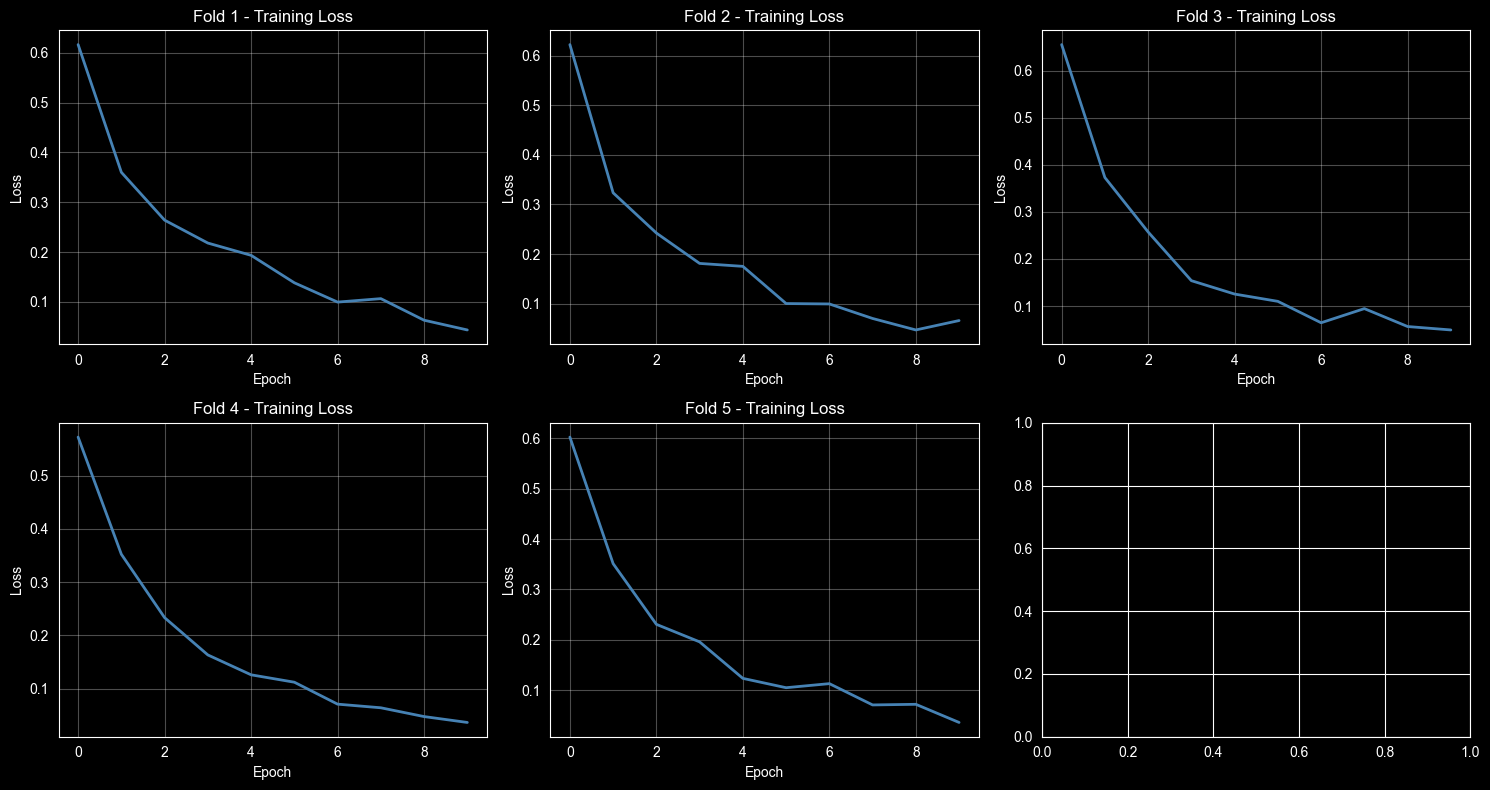

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, history in enumerate(training_history):
    ax = axes[i]
    ax.plot(history['losses'], linewidth=2, color='steelblue')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f"Fold {history['fold']} - Training Loss")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

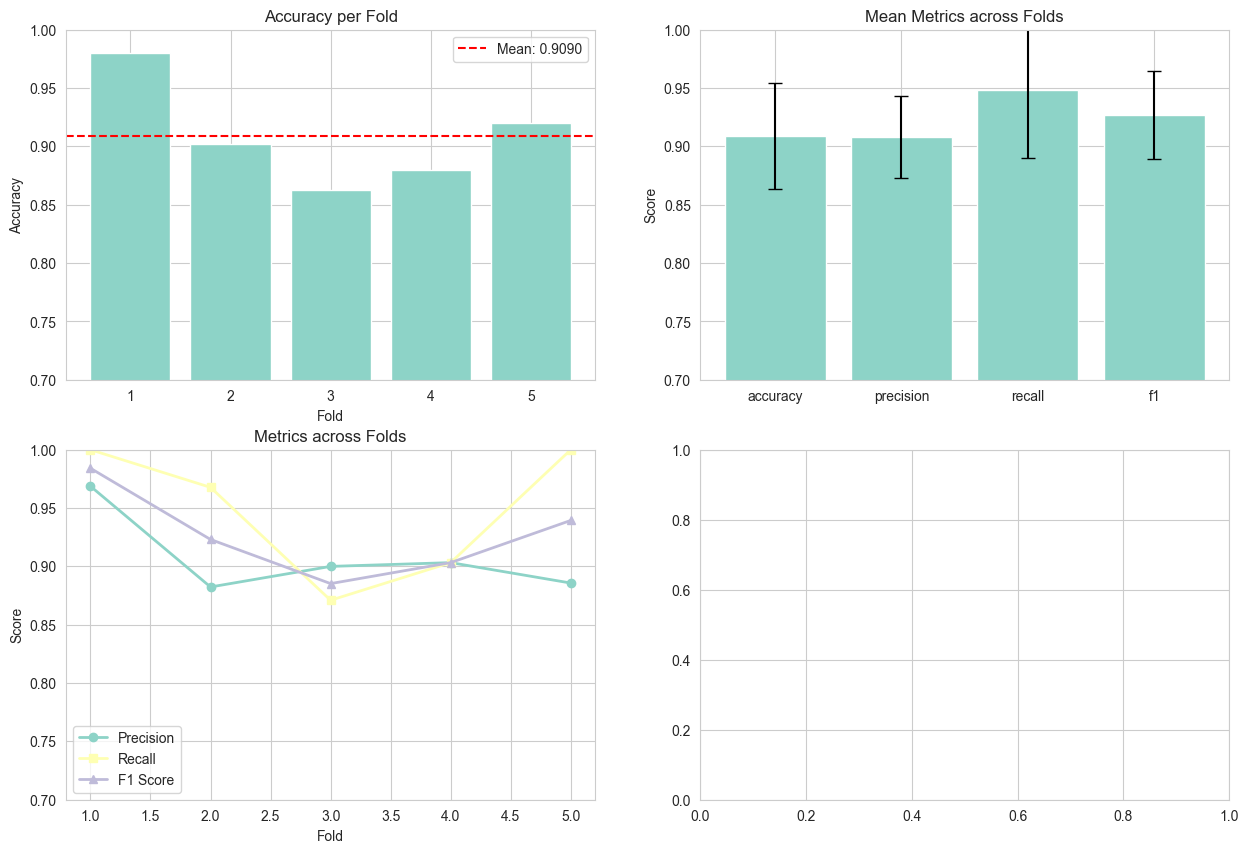

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
folds = results_df['fold'].values
acc = results_df['accuracy'].values
ax.bar(folds, acc)
ax.axhline(y=acc.mean(), color='r', linestyle='--', label=f'Mean: {acc.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy per Fold')
ax.set_ylim([0.7, 1.0])
ax.legend()

ax = axes[0, 1]
metrics = ['accuracy', 'precision', 'recall', 'f1']
means = [results_df[m].mean() for m in metrics]
stds = [results_df[m].std() for m in metrics]
ax.bar(metrics, means, yerr=stds, capsize=5)
ax.set_ylabel('Score')
ax.set_title('Mean Metrics across Folds')
ax.set_ylim([0.7, 1.0])



ax = axes[1, 0]
ax.plot(folds, results_df['precision'], 'o-', label='Precision', linewidth=2)
ax.plot(folds, results_df['recall'], 's-', label='Recall', linewidth=2)
ax.plot(folds, results_df['f1'], '^-', label='F1 Score', linewidth=2)
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('Metrics across Folds')
ax.legend()
ax.set_ylim([0.7, 1.0])


plt.show()


In [17]:
len(df_orig)

253

In [18]:
len(df_aug)

57

# Split using train test split ( 100 epochs )

- when we did the kfold cross validation , there was a technique we didnt use, and that is breaking it down into train, validation, test. when unseen data is used, it may show a large disparity between the actual performance and training performance
- we also used a higher batch size to increases training speed , but for a trade off of less frequent parameter updates

1. split 70% , 30% for train test split
2. using train we further split into 80% (train) and 20% (validation)
3. again we ensure that augmented data is not inside the test set or the validation set

In [19]:
from sklearn.model_selection import train_test_split

# first split : train 70%, test 30%
df_train_orig, df_test = train_test_split(
    df_orig,
    test_size=0.3,
    stratify=df_orig['label'],
    random_state=42,
    shuffle=True
)

# second split : training into train (80%) and validation (20%)
df_train_orig, df_val = train_test_split(
    df_train_orig,
    test_size=0.2,
    stratify=df_train_orig['label'],
    random_state=42,
    shuffle=True
)


sources_in_train = set(df_train_orig["filepath"])
df_aug_safe = df_aug[df_aug["source"].isin(sources_in_train)]

df_train = pd.concat([df_train_orig, df_aug_safe]).sample(frac=1, random_state=42).reset_index(drop=True)

X_train = torch.stack([torch.load(path) for path in df_train['tensor_path']])
y_train = torch.tensor(df_train['label'].values, dtype=torch.long)

X_val = torch.stack([torch.load(path) for path in df_val['tensor_path']])
y_val = torch.tensor(df_val['label'].values, dtype=torch.long)

X_test = torch.stack([torch.load(path) for path in df_test['tensor_path']])
y_test = torch.tensor(df_test['label'].values, dtype=torch.long)

print(f"Train: {len(df_train)}, label=0: {(y_train==0).sum()} | label=1: {(y_train==1).sum()}")

print(f"Test:  {len(df_test)}, label=0: {(y_test==0).sum()} | label=1: {(y_test==1).sum()}")
print(f"Aug injected: {len(df_aug_safe)}")

Train: 177, label=0: 91 | label=1: 86
Test:  76, label=0: 29 | label=1: 47
Aug injected: 36


# Stopping conditions

- every epoch we train it with a train set, reducing the loss function with SGD.
- for every epoch , we also test it against a evaluation set , if it improves, we save that current model state as the best .
- when testing it against the evaluation set and if it stops improving after X iterations, we break, no further improvements can be found likely, and it is likely overfitting



In [21]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
num_epochs = 100

train_dataset = TensorDataset(X_train, y_train)

# can afford smaller batch size
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# shuffle false here to improve reproducibility and stable comparisons across epochs
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=8, shuffle=False)


model = build_model()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


def train_model_loop(model, train_loader, val_loader, criterion, learning_rate=0.001,
                num_epochs=100, patience=10, device='cpu', save_path='best_model.pt'):

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)

            try:
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            except Exception as e:
                print(f"Error: {e}")
                import traceback
                traceback.print_exc()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"Val loss improved to {avg_val_loss:.4f}, model saved")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    # Load best model
    model.load_state_dict(torch.load(save_path))

    return {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss
    }

results = train_model_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    learning_rate=0.001,
    num_epochs=100,
    patience=10,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    save_path='best_model.pt'
)







Epoch 1/100, Train Loss: 0.6190, Val Loss: 0.4325
Val loss improved to 0.4325, model saved
Epoch 2/100, Train Loss: 0.3855, Val Loss: 0.3125
Val loss improved to 0.3125, model saved
Epoch 3/100, Train Loss: 0.3027, Val Loss: 0.2257
Val loss improved to 0.2257, model saved
Epoch 4/100, Train Loss: 0.2603, Val Loss: 0.2197
Val loss improved to 0.2197, model saved
Epoch 5/100, Train Loss: 0.2300, Val Loss: 0.2197
Val loss improved to 0.2197, model saved
Epoch 6/100, Train Loss: 0.2254, Val Loss: 0.1561
Val loss improved to 0.1561, model saved
Epoch 7/100, Train Loss: 0.1465, Val Loss: 0.1850
Epoch 8/100, Train Loss: 0.2144, Val Loss: 0.2246
Epoch 9/100, Train Loss: 0.1667, Val Loss: 0.1361
Val loss improved to 0.1361, model saved
Epoch 10/100, Train Loss: 0.1294, Val Loss: 0.1291
Val loss improved to 0.1291, model saved
Epoch 11/100, Train Loss: 0.1441, Val Loss: 0.1460
Epoch 12/100, Train Loss: 0.0923, Val Loss: 0.1996
Epoch 13/100, Train Loss: 0.1284, Val Loss: 0.1866
Epoch 14/100, Trai

In [22]:
model = results["model"]



# Increasing epoch
- here we can see that increasing epochs decreases the loss , up to a point of convergence.
- After that point, the model starts to overfit on the data

# Test it on test set


- this test set is unseen by the model up til now

In [28]:
import torch.nn.functional as F

model.load_state_dict(torch.load('best_model.pt'))
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    y_pred = torch.argmax(outputs, dim=1).cpu().numpy()
    probs = F.softmax(outputs, dim=1).cpu().numpy()




y_test_np = y_test.numpy()

misclassified_idx = np.where(y_pred != y_test_np)[0]


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)



print(f"\nResults:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

X_test shape: 76
y_pred shape: 76
y_test shape: 76
probs shape: 76
Max index in misclassified_idx: 56

Results:
Accuracy:  0.8684
Precision: 0.8776
Recall:    0.9149
F1 Score:  0.8958


In [29]:
print(f"X_test shape: {X_test.shape[0]}")
print(f"y_pred shape: {y_pred.shape[0]}")
print(f"y_test shape: {y_test_np.shape[0]}")
print(f"probs shape: {probs.shape[0]}")
print(f"Max index in misclassified_idx: {misclassified_idx.max()}")

X_test shape: 76
y_pred shape: 76
y_test shape: 76
probs shape: 76
Max index in misclassified_idx: 56


In [27]:
len(misclassified_idx)

10

# Looking at misclassified images

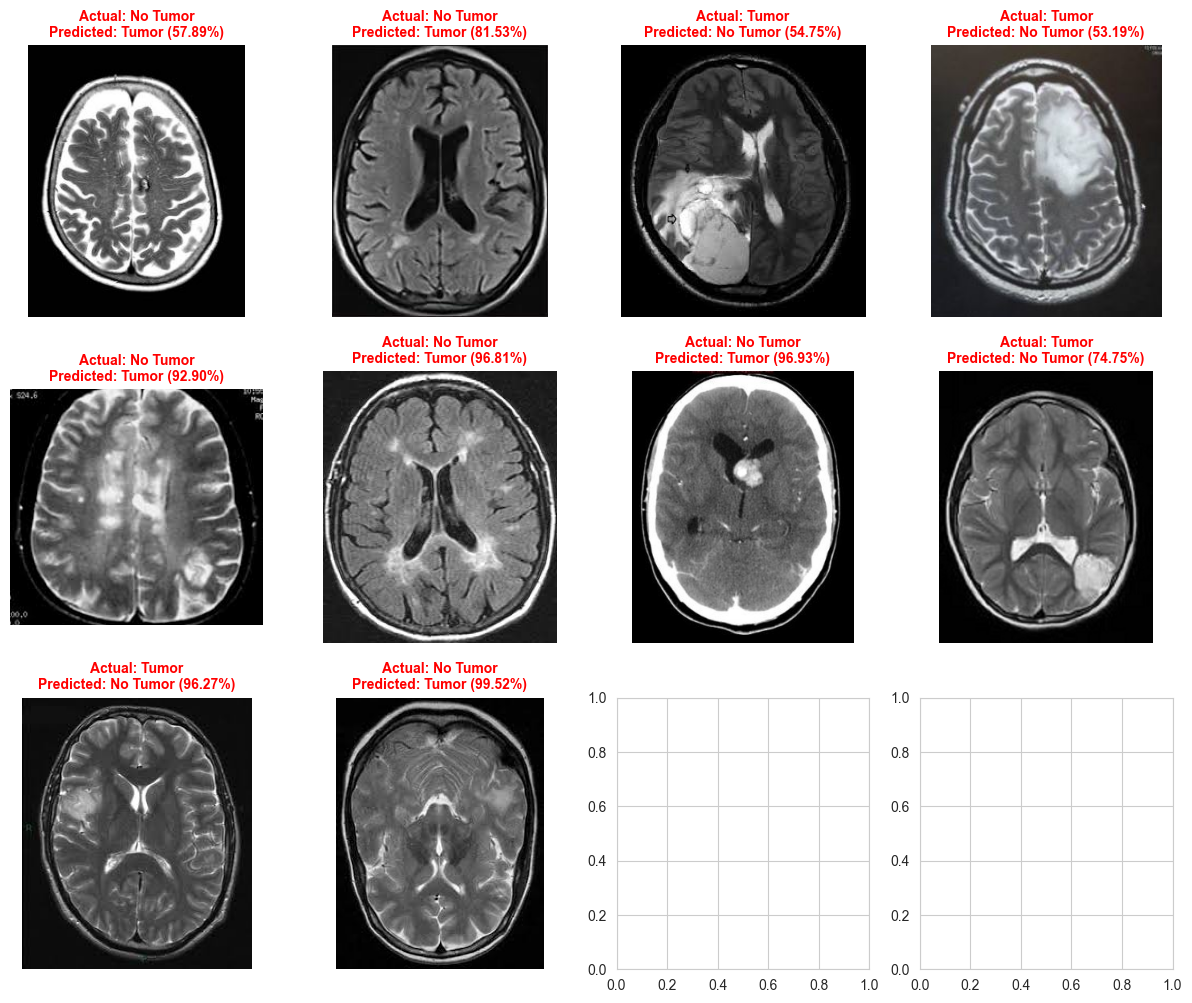

In [30]:


label_names = {0: 'No Tumor', 1: 'Tumor'}

def plot_misclassified(misclassified_idx, y_pred, y_test_np, df_test, label_names, probs, data_dir='data/'):

    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    axes = axes.flatten()

    for idx, plot_idx in enumerate(misclassified_idx[:12]):
        ax = axes[idx]

        # Get original image path
        image_path = data_dir + df_test.iloc[plot_idx]['image_path']
        actual_label = y_test_np[plot_idx]
        pred_label = y_pred[plot_idx]
        pred_prob = probs[plot_idx][pred_label]


        # Load and display original image
        img = Image.open(image_path).convert('RGB')
        ax.imshow(img)

        # Title with prediction vs actual
        title = f"Actual: {label_names[actual_label]}\nPredicted: {label_names[pred_label]} ({pred_prob:.2%})"
        color = 'red'  # Wrong prediction
        ax.set_title(title, fontsize=10, fontweight='bold', color=color)
        ax.axis('off')

    return fig, axes

fig, axes = plot_misclassified(misclassified_idx, y_pred, y_test_np, df_test, label_names, probs)

plt.show()

# Looking at the misclassifications

- seems like the misclassifications, likely stems from colour contrast.
- healthy brain scans still have slight localised colour contrast, this may have contributed to the noise
- model is likely picking up on these subtle contrast patterns as tumor-like

In [31]:
results.keys()

dict_keys(['model', 'train_losses', 'val_losses', 'best_val_loss'])

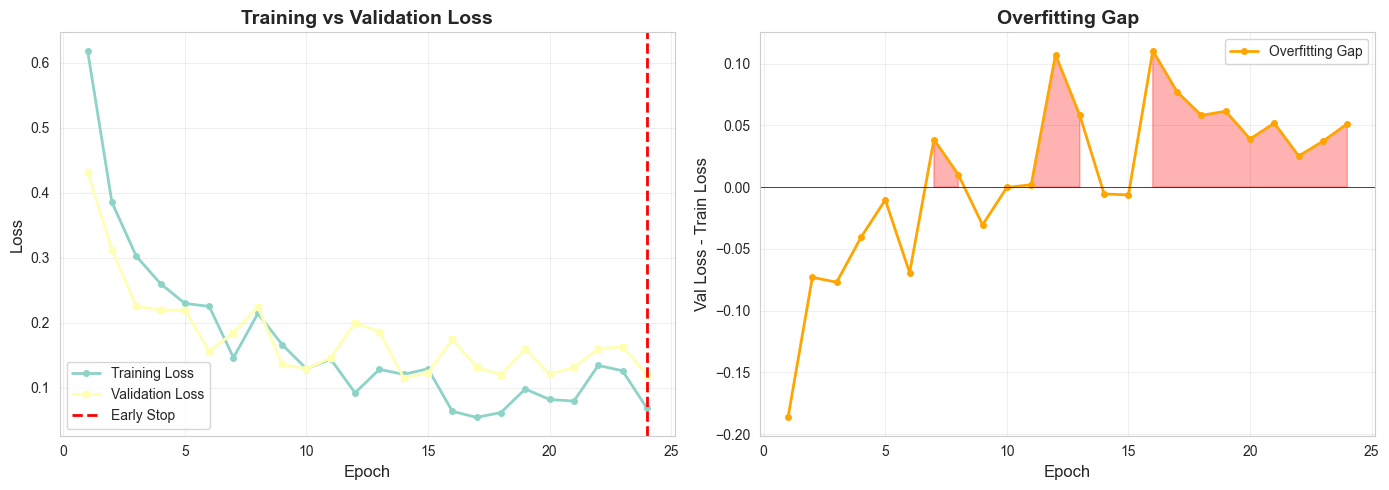

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(train_losses, val_losses, figsize=(14, 5), title_prefix='',
                          compare_train_losses=None, compare_val_losses=None,
                          compare_label='', ylim=None):



    fig, axes = plt.subplots(1, 2, figsize=figsize)

    ax = axes[0]
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, 'o-', label='Training Loss', linewidth=2, markersize=4)
    ax.plot(epochs, val_losses, 's-', label='Validation Loss', linewidth=2, markersize=4)
    ax.axvline(x=len(train_losses), color='red', linestyle='--', label='Early Stop', linewidth=2)

    if compare_train_losses is not None:
        compare_epochs = range(1, len(compare_train_losses) + 1)
        ax.plot(compare_epochs, compare_train_losses, 'o--', label=f'{compare_label} Training Loss',
                linewidth=2, markersize=4, alpha=0.7)
        ax.plot(compare_epochs, compare_val_losses, 's--', label=f'{compare_label} Validation Loss',
                linewidth=2, markersize=4, alpha=0.7)

    if ylim:
        ax.set_ylim(ylim)

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'{title_prefix}Training vs Validation Loss', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    loss_diff = np.array(val_losses) - np.array(train_losses)
    ax.plot(epochs, loss_diff, 'o-', color='orange', linewidth=2, markersize=4, label='Overfitting Gap')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.fill_between(epochs, loss_diff, 0, where=(loss_diff > 0), alpha=0.3, color='red')

    if compare_train_losses is not None:
        compare_loss_diff = np.array(compare_val_losses) - np.array(compare_train_losses)
        compare_epochs = range(1, len(compare_train_losses) + 1)
        ax.plot(compare_epochs, compare_loss_diff, 'o--', color='darkorange',
                linewidth=2, markersize=4, label=f'{compare_label} Gap', alpha=0.7)
        ax.fill_between(compare_epochs, compare_loss_diff, 0, where=(compare_loss_diff > 0),
                        alpha=0.2, color='red')

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Val Loss - Train Loss', fontsize=12)
    ax.set_title(f'{title_prefix}Overfitting Gap', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    return fig, axes


train_losses = results['train_losses']
val_losses = results['val_losses']

fig1, axes = plot_training_history(
    train_losses=results['train_losses'],
    val_losses=results['val_losses']
)





# Overfitting

- overfitting gap seems to increase after 20 epochs , however we have saved the model before the overfitting occured



# Progressive Fine tuning

- Progressive fine-tuning can further improve accuracy by gradually unfreezing and training deeper layers
- This approach allows the model to adapt earlier layers to better suit the specific use case, while maintaining learned features from pre-training

In [34]:
for param in model.features[-2:].parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

results_ft_1 = train_model_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    learning_rate=0.0001,
    num_epochs=100,
    patience=10,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    save_path='ft1.pt'
)



Epoch 1/100, Train Loss: 0.1063, Val Loss: 0.0991
Val loss improved to 0.0991, model saved
Epoch 2/100, Train Loss: 0.0928, Val Loss: 0.1052
Epoch 3/100, Train Loss: 0.1340, Val Loss: 0.1142
Epoch 4/100, Train Loss: 0.0902, Val Loss: 0.2049
Epoch 5/100, Train Loss: 0.1014, Val Loss: 0.1992
Epoch 6/100, Train Loss: 0.0535, Val Loss: 0.1783
Epoch 7/100, Train Loss: 0.0913, Val Loss: 0.1501
Epoch 8/100, Train Loss: 0.0917, Val Loss: 0.1854
Epoch 9/100, Train Loss: 0.0950, Val Loss: 0.1873
Epoch 10/100, Train Loss: 0.0887, Val Loss: 0.1208
Epoch 11/100, Train Loss: 0.0592, Val Loss: 0.1076

Early stopping at epoch 11


In [35]:
model.load_state_dict(torch.load('ft1.pt'))
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    y_pred = torch.argmax(outputs, dim=1).cpu().numpy()
    probs = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy()

y_test_np = y_test.numpy()

misclassified_idx = np.where(y_pred != y_test_np)[0]


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)



print(f"\nResults:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")



Results:
Accuracy:  0.8947
Precision: 0.8679
Recall:    0.9787
F1 Score:  0.9200


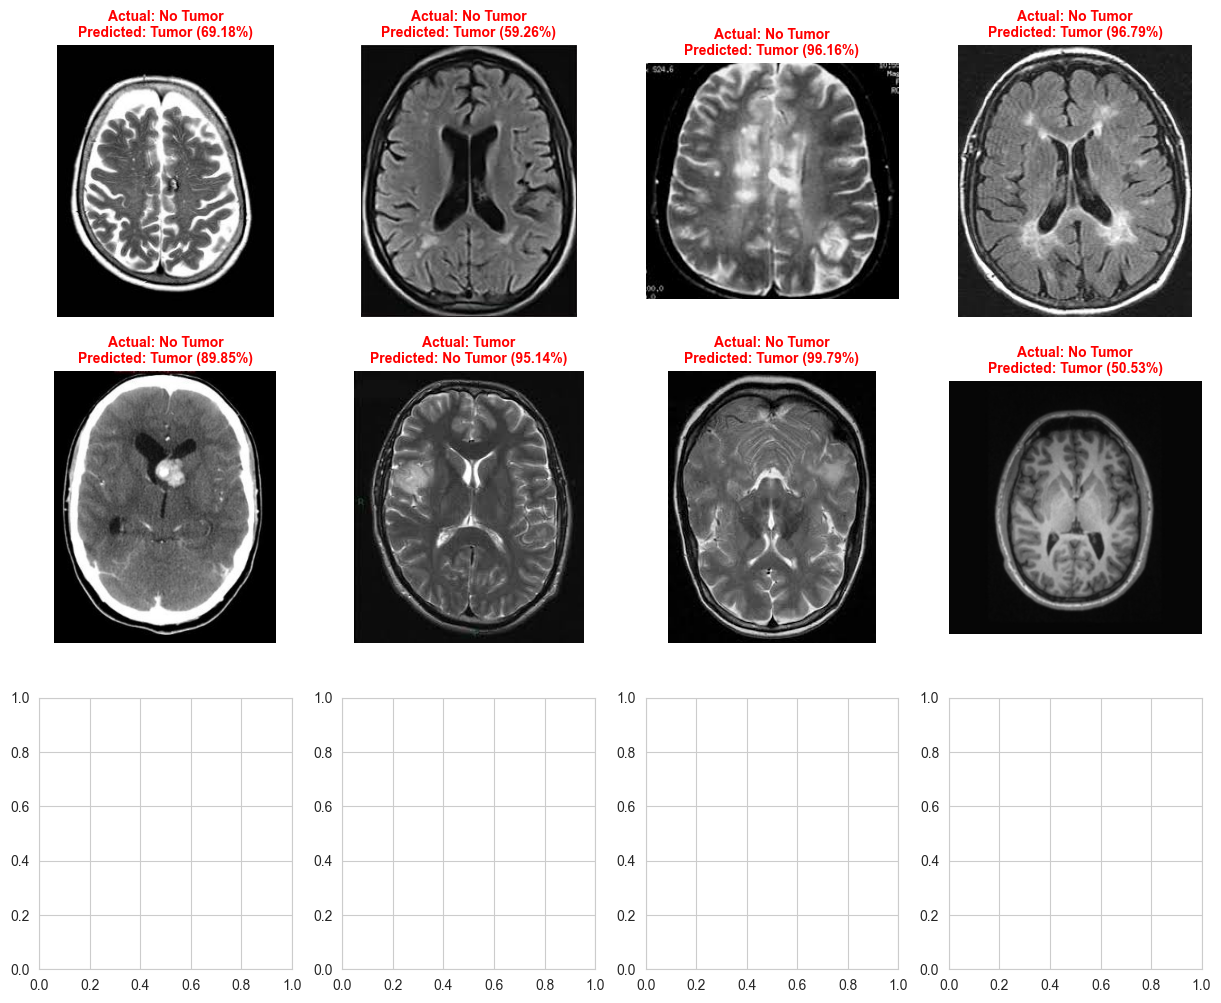

In [36]:
fig, axes = plot_misclassified(misclassified_idx, y_pred, y_test_np, df_test, label_names, probs)

plt.show()

# Comparing the misclassifications

- After fine-tuning, the model correctly predicts visually distinctive images that were previously misclassified
- Prediction confidence decreased for several incorrect predictions
- Some incorrect predictions showed increased confidence, though the magnitude was small and these cases were fewer in number



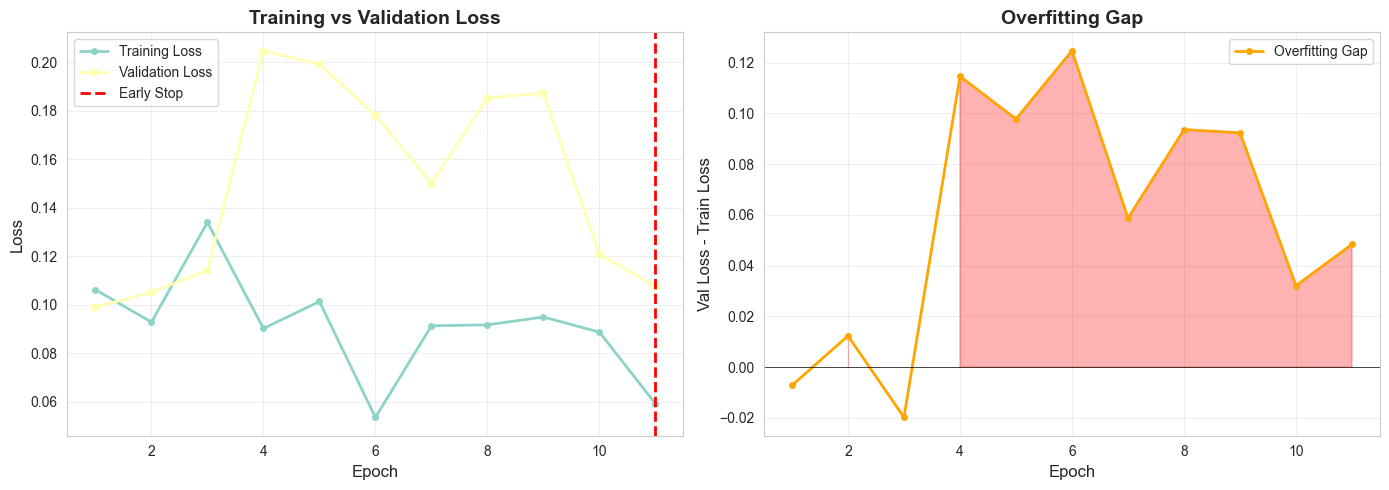

In [39]:
train_losses = results_ft_1['train_losses']
val_losses = results_ft_1['val_losses']

fig2, axes = plot_training_history(
    train_losses=results_ft_1['train_losses'],
    val_losses=results_ft_1['val_losses']
)

plt.show()


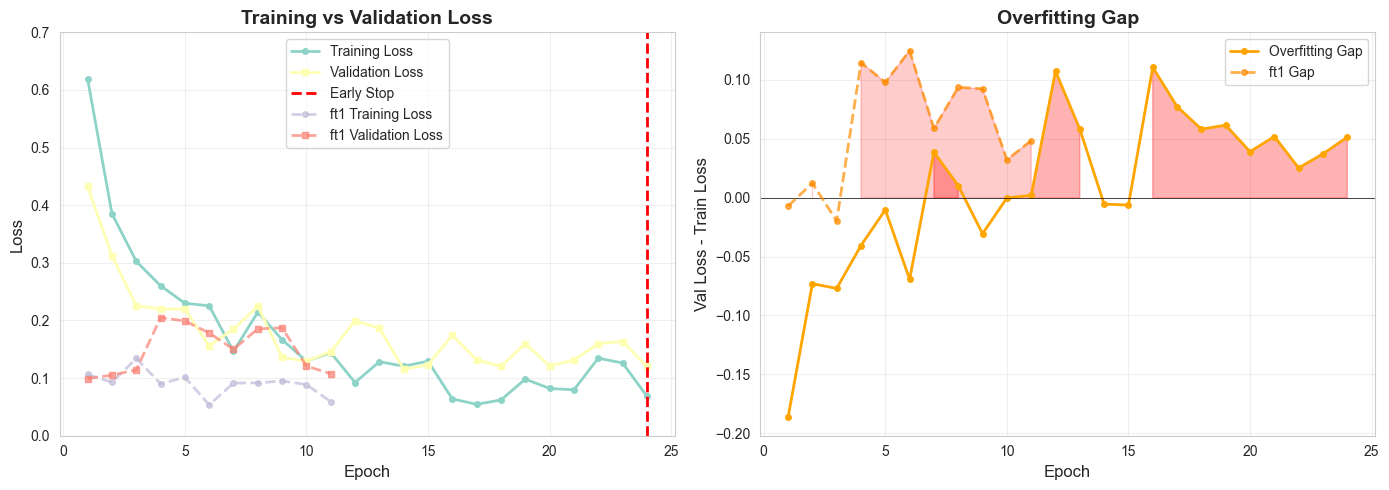

In [40]:
fig, axes = plot_training_history(
    train_losses=results['train_losses'],
    val_losses=results['val_losses'],
    compare_train_losses=results_ft_1['train_losses'],
    compare_val_losses=results_ft_1['val_losses'],
    compare_label='ft1',
    ylim=(0, 0.7)
)
plt.show()

